In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, f1_score,classification_report, confusion_matrix)
import joblib

In [2]:
# Paths
DATA_DIR   = Path("../data/processed/tabular_data")
MODELS_DIR  = Path("../data/models")
FIGURES_DIR = Path("../data/figures/04_model_training")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
(FIGURES_DIR / "baseline").mkdir(exist_ok=True)
(FIGURES_DIR / "tuned").mkdir(exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

# Load splits
train_df = pd.read_csv(DATA_DIR / "train.csv")
val_df   = pd.read_csv(DATA_DIR / "val.csv")
test_df  = pd.read_csv(DATA_DIR / "test.csv")

# Separate features and labels
LABEL_COLS = ["exercise_name_encoded", "exercise_correctness_encoded", "video_id", "frame_number"]
feature_cols = [c for c in train_df.columns if c not in LABEL_COLS]

# 26-feature matrix — used by exercise classifiers only.
# exercise_name_encoded must NOT be a feature for exercise models (it is the target).
X_train = train_df[feature_cols]
X_val   = val_df[feature_cols]
X_test  = test_df[feature_cols]

# 27-feature matrix — used by correctness classifiers only.
# Appends exercise_name_encoded (0-3 integer) so each model learns
# "correct form for THIS exercise" rather than a cross-exercise average.
X_train_cor = pd.concat([X_train, train_df[["exercise_name_encoded"]]], axis=1)
X_val_cor   = pd.concat([X_val,   val_df  [["exercise_name_encoded"]]], axis=1)
X_test_cor  = pd.concat([X_test,  test_df [["exercise_name_encoded"]]], axis=1)

y_ex_train,  y_cor_train  = train_df["exercise_name_encoded"],  train_df["exercise_correctness_encoded"]
y_ex_val,    y_cor_val    = val_df["exercise_name_encoded"],    val_df["exercise_correctness_encoded"]
y_ex_test,   y_cor_test   = test_df["exercise_name_encoded"],   test_df["exercise_correctness_encoded"]

print("✅ Splits loaded.")
print(f"   Train (ex)  : {X_train.shape}     Train (cor) : {X_train_cor.shape}")
print(f"   Val   (ex)  : {X_val.shape}     Val   (cor) : {X_val_cor.shape}")
print(f"   Test  (ex)  : {X_test.shape}     Test  (cor) : {X_test_cor.shape}")


✅ Splits loaded.
   Train (ex)  : (18608, 26)     Train (cor) : (18608, 27)
   Val   (ex)  : (4304, 26)     Val   (cor) : (4304, 27)
   Test  (ex)  : (4139, 26)     Test  (cor) : (4139, 27)


In [3]:
EXERCISE_NAMES    = {0: "pullup", 1: "pushup", 2: "russian_twist", 3: "squat"}
CORRECTNESS_NAMES = {0: "incorrect", 1: "correct"}

def evaluate_model(model, X, y, label_map, model_name, task_name, split_name):
    """
    Evaluates a trained model on a given split.
    Prints classification report and plots confusion matrix.
    """
    label_names = [label_map[k] for k in sorted(label_map.keys())]
    y_pred = model.predict(X)
    acc    = accuracy_score(y, y_pred)
    f1     = f1_score(y, y_pred, average="weighted")

    print(f"\n{'='*50}")
    print(f"  {model_name} — {task_name} [{split_name}]")
    print(f"{'='*50}")
    print(f"  Accuracy : {acc:.4f}")
    print(f"  F1 Score : {f1:.4f} (weighted)")
    print(f"\n{classification_report(y, y_pred, target_names=label_names)}")

    # Confusion matrix
    cm = confusion_matrix(y, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=label_names, yticklabels=label_names)
    plt.title(f"{model_name} — {task_name} [{split_name}]")
    plt.ylabel("True Label")
    plt.xlabel("Predicted Label")
    plt.tight_layout()
    subfolder = "tuned" if "(tuned)" in model_name.lower() else "baseline"
    fig_path  = FIGURES_DIR / subfolder / f"cm_{model_name.lower().replace(' ', '_')}_{task_name.lower().replace(' ', '_')}_{split_name.lower()}.png"
    fig_path.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(fig_path, dpi=150, bbox_inches="tight")
    plt.show()

    return {"model": model_name, "task": task_name, "split": split_name, "accuracy": acc, "f1": f1}

print("✅ Evaluation helper function defined.")

✅ Evaluation helper function defined.


✅ Random Forest (Exercise) trained.

  Random Forest — Exercise Classification [Validation]
  Accuracy : 0.9944
  F1 Score : 0.9944 (weighted)

               precision    recall  f1-score   support

       pullup       0.98      1.00      0.99       985
       pushup       1.00      1.00      1.00      1034
russian_twist       1.00      1.00      1.00      1142
        squat       1.00      0.98      0.99      1143

     accuracy                           0.99      4304
    macro avg       0.99      0.99      0.99      4304
 weighted avg       0.99      0.99      0.99      4304



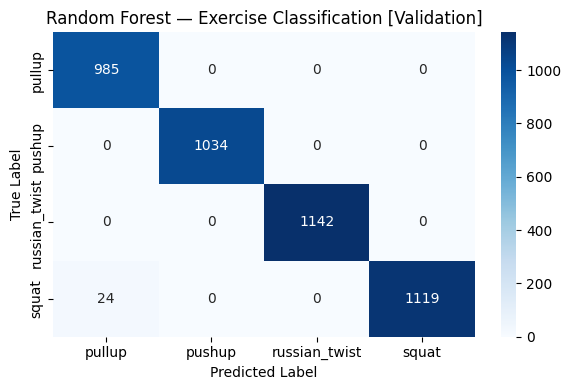


💾 Model saved → ..\data\models\rf_exercise.pkl


In [4]:
rf_exercise = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_exercise.fit(X_train, y_ex_train)
print("✅ Random Forest (Exercise) trained.")

# Evaluate on validation set only
results_rf_ex = evaluate_model(
    model      = rf_exercise,
    X          = X_val,
    y          = y_ex_val,
    label_map  = EXERCISE_NAMES,
    model_name = "Random Forest",
    task_name  = "Exercise Classification",
    split_name = "Validation"
)

# Save model
joblib.dump(rf_exercise, MODELS_DIR / "rf_exercise.pkl")
print(f"\n💾 Model saved → {MODELS_DIR / 'rf_exercise.pkl'}")

✅ Random Forest (Correctness) trained.

  Random Forest — Correctness Classification [Validation]
  Accuracy : 0.7990
  F1 Score : 0.7990 (weighted)

              precision    recall  f1-score   support

   incorrect       0.79      0.81      0.80      2114
     correct       0.81      0.79      0.80      2190

    accuracy                           0.80      4304
   macro avg       0.80      0.80      0.80      4304
weighted avg       0.80      0.80      0.80      4304



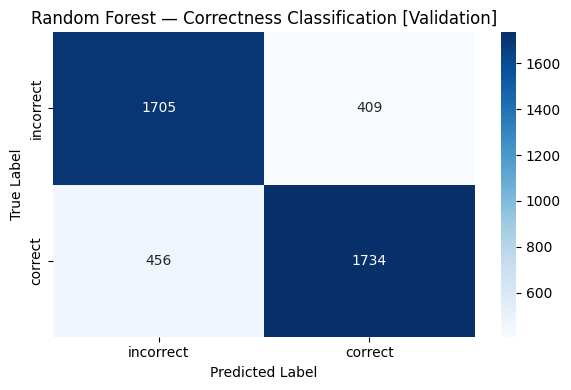


💾 Model saved → ..\data\models\rf_correctness.pkl


In [5]:
rf_correctness = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    class_weight="balanced",   # handles correct/incorrect imbalance
    random_state=42,
    n_jobs=-1
)

rf_correctness.fit(X_train_cor, y_cor_train)
print("✅ Random Forest (Correctness) trained.")

# Evaluate on validation set only
results_rf_cor = evaluate_model(
    model      = rf_correctness,
    X          = X_val_cor,
    y          = y_cor_val,
    label_map  = CORRECTNESS_NAMES,
    model_name = "Random Forest",
    task_name  = "Correctness Classification",
    split_name = "Validation"
)

# Save model
joblib.dump(rf_correctness, MODELS_DIR / "rf_correctness.pkl")
print(f"\n💾 Model saved → {MODELS_DIR / 'rf_correctness.pkl'}")


✅ SVM (Exercise) trained.

  SVM — Exercise Classification [Validation]
  Accuracy : 0.9898
  F1 Score : 0.9898 (weighted)

               precision    recall  f1-score   support

       pullup       0.96      1.00      0.98       985
       pushup       1.00      1.00      1.00      1034
russian_twist       1.00      1.00      1.00      1142
        squat       1.00      0.97      0.98      1143

     accuracy                           0.99      4304
    macro avg       0.99      0.99      0.99      4304
 weighted avg       0.99      0.99      0.99      4304



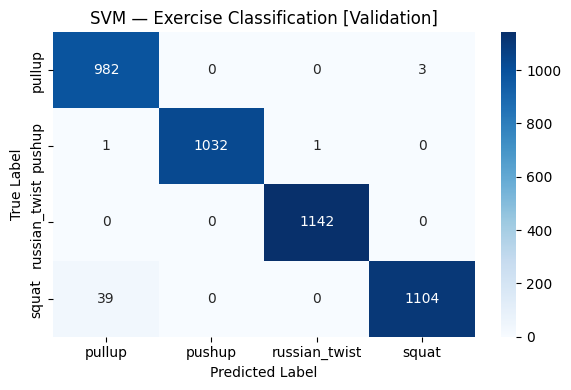


💾 Model saved → ..\data\models\svm_exercise.pkl


In [6]:
svm_exercise = SVC(
    kernel="rbf",        # handles non-linear boundaries between exercise types
    C=10,                # regularization — higher C = less margin tolerance
    gamma="scale",       # automatically scales with number of features
    class_weight="balanced",
    random_state=42
)

svm_exercise.fit(X_train, y_ex_train)
print("✅ SVM (Exercise) trained.")

# Evaluate on validation set only
results_svm_ex = evaluate_model(
    model      = svm_exercise,
    X          = X_val,
    y          = y_ex_val,
    label_map  = EXERCISE_NAMES,
    model_name = "SVM",
    task_name  = "Exercise Classification",
    split_name = "Validation"
)

# Save model
joblib.dump(svm_exercise, MODELS_DIR / "svm_exercise.pkl")
print(f"\n💾 Model saved → {MODELS_DIR / 'svm_exercise.pkl'}")

✅ SVM (Correctness) trained.

  SVM — Correctness Classification [Validation]
  Accuracy : 0.7693
  F1 Score : 0.7693 (weighted)

              precision    recall  f1-score   support

   incorrect       0.77      0.76      0.76      2114
     correct       0.77      0.77      0.77      2190

    accuracy                           0.77      4304
   macro avg       0.77      0.77      0.77      4304
weighted avg       0.77      0.77      0.77      4304



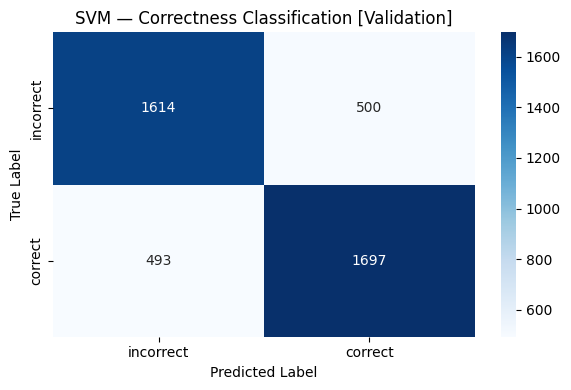


💾 Model saved → ..\data\models\svm_correctness.pkl


In [7]:
svm_correctness = SVC(
    kernel="rbf",
    C=10,
    gamma="scale",
    class_weight="balanced",
    random_state=42
)

svm_correctness.fit(X_train_cor, y_cor_train)
print("✅ SVM (Correctness) trained.")

# Evaluate on validation set only
results_svm_cor = evaluate_model(
    model      = svm_correctness,
    X          = X_val_cor,
    y          = y_cor_val,
    label_map  = CORRECTNESS_NAMES,
    model_name = "SVM",
    task_name  = "Correctness Classification",
    split_name = "Validation"
)

# Save model
joblib.dump(svm_correctness, MODELS_DIR / "svm_correctness.pkl")
print(f"\n💾 Model saved → {MODELS_DIR / 'svm_correctness.pkl'}")


In [8]:
# ── Learning curves & OOB error (optional diagnostics) ─────────────────────
# Uncomment and run this block after initial training to inspect overfitting.
# Requires: sklearn.model_selection.learning_curve
#
# from sklearn.model_selection import learning_curve
# (full plotting code removed — retrieve from git history if needed)
print('Skipped: learning curves / OOB diagnostics (optional — see git history).')

Skipped: learning curves / OOB diagnostics (optional — see git history).


🔬 Running final evaluation on TEST SET for all models...


  Random Forest — Exercise Classification [Test]
  Accuracy : 0.9990
  F1 Score : 0.9990 (weighted)

               precision    recall  f1-score   support

       pullup       1.00      1.00      1.00       976
       pushup       1.00      1.00      1.00      1080
russian_twist       1.00      1.00      1.00      1035
        squat       1.00      1.00      1.00      1048

     accuracy                           1.00      4139
    macro avg       1.00      1.00      1.00      4139
 weighted avg       1.00      1.00      1.00      4139



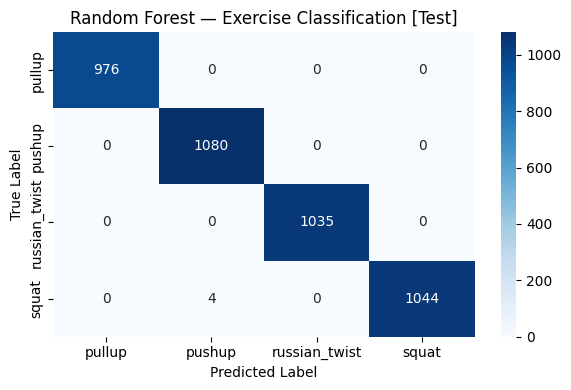


  Random Forest — Correctness Classification [Test]
  Accuracy : 0.8166
  F1 Score : 0.8157 (weighted)

              precision    recall  f1-score   support

   incorrect       0.77      0.89      0.83      2051
     correct       0.87      0.74      0.80      2088

    accuracy                           0.82      4139
   macro avg       0.82      0.82      0.82      4139
weighted avg       0.82      0.82      0.82      4139



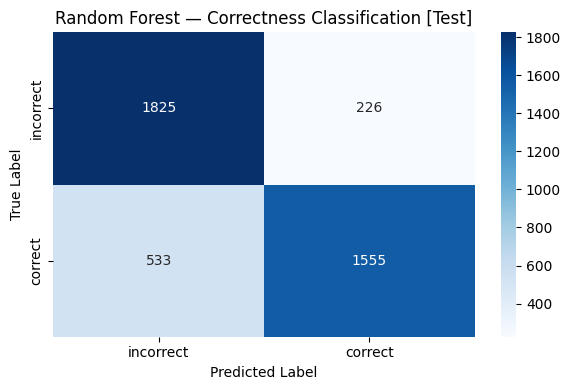


  SVM — Exercise Classification [Test]
  Accuracy : 0.9978
  F1 Score : 0.9978 (weighted)

               precision    recall  f1-score   support

       pullup       0.99      1.00      1.00       976
       pushup       1.00      1.00      1.00      1080
russian_twist       1.00      1.00      1.00      1035
        squat       1.00      0.99      1.00      1048

     accuracy                           1.00      4139
    macro avg       1.00      1.00      1.00      4139
 weighted avg       1.00      1.00      1.00      4139



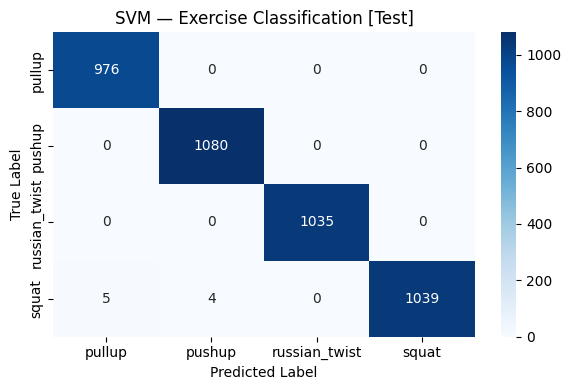


  SVM — Correctness Classification [Test]
  Accuracy : 0.8062
  F1 Score : 0.8055 (weighted)

              precision    recall  f1-score   support

   incorrect       0.77      0.87      0.82      2051
     correct       0.85      0.74      0.79      2088

    accuracy                           0.81      4139
   macro avg       0.81      0.81      0.81      4139
weighted avg       0.81      0.81      0.81      4139



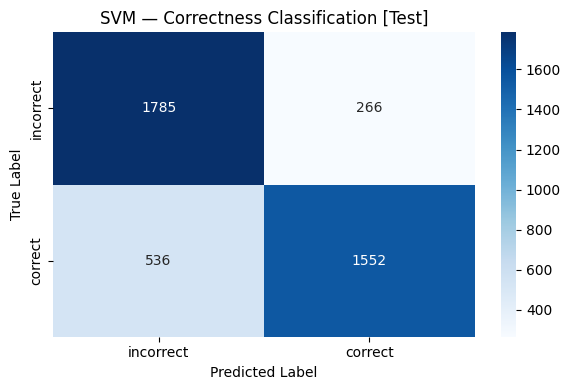


        FINAL MODEL COMPARISON — TEST SET


,model,task,accuracy,f1
0,Random Forest,Exercise Classification,0.9990,0.9990
1,Random Forest,Correctness Classification,0.8166,0.8157
2,SVM,Exercise Classification,0.9978,0.9978
3,SVM,Correctness Classification,0.8062,0.8055



💾 Comparison table saved → ..\data\models\model_comparison.csv


In [9]:
print("🔬 Running final evaluation on TEST SET for all models...\n")

# Evaluate all 4 models on test set
test_results = []

test_results.append(evaluate_model(
    model      = rf_exercise,
    X          = X_test,
    y          = y_ex_test,
    label_map  = EXERCISE_NAMES,
    model_name = "Random Forest",
    task_name  = "Exercise Classification",
    split_name = "Test"
))

test_results.append(evaluate_model(
    model      = rf_correctness,
    X          = X_test_cor,
    y          = y_cor_test,
    label_map  = CORRECTNESS_NAMES,
    model_name = "Random Forest",
    task_name  = "Correctness Classification",
    split_name = "Test"
))

test_results.append(evaluate_model(
    model      = svm_exercise,
    X          = X_test,
    y          = y_ex_test,
    label_map  = EXERCISE_NAMES,
    model_name = "SVM",
    task_name  = "Exercise Classification",
    split_name = "Test"
))

test_results.append(evaluate_model(
    model      = svm_correctness,
    X          = X_test_cor,
    y          = y_cor_test,
    label_map  = CORRECTNESS_NAMES,
    model_name = "SVM",
    task_name  = "Correctness Classification",
    split_name = "Test"
))

# Build comparison table
results_df = pd.DataFrame(test_results)[["model", "task", "accuracy", "f1"]]
results_df["accuracy"] = results_df["accuracy"].round(4)
results_df["f1"]       = results_df["f1"].round(4)

print("\n" + "="*60)
print("        FINAL MODEL COMPARISON — TEST SET")
print("="*60)
display(results_df)

# Save comparison table
results_df.to_csv(MODELS_DIR / "model_comparison.csv", index=False)
print(f"\n💾 Comparison table saved → {MODELS_DIR / 'model_comparison.csv'}")


In [11]:
from sklearn.model_selection import GridSearchCV, StratifiedGroupKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42

# ── Video-level folds ─────────────────────────────────────────
# StratifiedGroupKFold ensures:
#   1. No video's frames appear in both the fold-train and fold-val partitions
#      (groups=video_id), fixing the frame-leakage that StratifiedKFold had.
#   2. Class ratios are preserved across folds (stratified).
# With 170 training videos and 5 folds, each fold-val has ~34 videos.
CV = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Groups vector: one entry per frame, value = its video_id.
# Passed to search.fit() so the CV splitter keeps all frames from the
# same video on the same side of every fold boundary.
train_groups = train_df["video_id"].values

rf_param_grid = {
    "n_estimators":     [200, 300],
    "max_depth":        [None, 10, 20],
    "min_samples_leaf": [1, 2, 5],
    "max_features":     ["sqrt", "log2", 0.3],
    "class_weight":     ["balanced"],
}
# 2 × 3 × 3 × 3 = 54 combinations × 5 folds = 270 fits

svm_param_grid = {
    "C":            [0.1, 1, 10, 100],
    "gamma":        ["scale", "auto", 0.001, 0.01, 0.1],
    "kernel":       ["rbf"],
    "class_weight": ["balanced"],
}
# 4 × 5 = 20 combinations × 5 folds = 100 fits

# ── Helper ────────────────────────────────────────────────────
def run_search(estimator, param_grid, X, y, groups, task_name):
    print(f"\n🔍 Tuning {estimator.__class__.__name__} — {task_name}")
    search = GridSearchCV(
        estimator,
        param_grid,
        scoring="f1_weighted",
        cv=CV,
        n_jobs=2,
        verbose=1,
        refit=True,
    )
    search.fit(X, y, groups=groups)
    print(f"  ✅ Best CV F1  : {search.best_score_:.4f}")
    print(f"  📋 Best params : {search.best_params_}")
    return search.best_estimator_, search.best_params_, search.best_score_

# ── Tune RF correctness (27 features: pose + exercise identity) ───────────────
rf_cor_tuned, rf_cor_params, rf_cor_cv = run_search(
    RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=2),
    rf_param_grid,
    X_train_cor, y_cor_train,
    groups=train_groups,
    task_name="Correctness Classification",
)

# ── Tune SVM correctness (27 features: pose + exercise identity) ──────────────
svm_cor_tuned, svm_cor_params, svm_cor_cv = run_search(
    SVC(random_state=RANDOM_STATE, probability=True),
    svm_param_grid,
    X_train_cor, y_cor_train,
    groups=train_groups,
    task_name="Correctness Classification",
)

# ── Tune RF exercise (26 features) ───────────────────────────────────────────
rf_ex_tuned, rf_ex_params, rf_ex_cv = run_search(
    RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=2),
    rf_param_grid,
    X_train, y_ex_train,
    groups=train_groups,
    task_name="Exercise Classification",
)

# ── Tune SVM exercise (26 features) ──────────────────────────────────────────
svm_ex_tuned, svm_ex_params, svm_ex_cv = run_search(
    SVC(random_state=RANDOM_STATE, probability=True),
    svm_param_grid,
    X_train, y_ex_train,
    groups=train_groups,
    task_name="Exercise Classification",
)



🔍 Tuning RandomForestClassifier — Correctness Classification
Fitting 5 folds for each of 54 candidates, totalling 270 fits
  ✅ Best CV F1  : 0.6613
  📋 Best params : {'class_weight': 'balanced', 'max_depth': None, 'max_features': 0.3, 'min_samples_leaf': 1, 'n_estimators': 300}

🔍 Tuning SVC — Correctness Classification
Fitting 5 folds for each of 20 candidates, totalling 100 fits
  ✅ Best CV F1  : 0.6847
  📋 Best params : {'C': 100, 'class_weight': 'balanced', 'gamma': 0.01, 'kernel': 'rbf'}

🔍 Tuning RandomForestClassifier — Exercise Classification
Fitting 5 folds for each of 54 candidates, totalling 270 fits
  ✅ Best CV F1  : 0.9933
  📋 Best params : {'class_weight': 'balanced', 'max_depth': None, 'max_features': 'log2', 'min_samples_leaf': 1, 'n_estimators': 300}

🔍 Tuning SVC — Exercise Classification
Fitting 5 folds for each of 20 candidates, totalling 100 fits
  ✅ Best CV F1  : 0.9919
  📋 Best params : {'C': 100, 'class_weight': 'balanced', 'gamma': 'scale', 'kernel': 'rbf'}



  TUNED MODEL RESULTS — TEST SET

  RF (tuned) — Exercise Classification [Test]
  Accuracy : 0.9993
  F1 Score : 0.9993 (weighted)

               precision    recall  f1-score   support

       pullup       1.00      1.00      1.00       976
       pushup       1.00      1.00      1.00      1080
russian_twist       1.00      1.00      1.00      1035
        squat       1.00      1.00      1.00      1048

     accuracy                           1.00      4139
    macro avg       1.00      1.00      1.00      4139
 weighted avg       1.00      1.00      1.00      4139



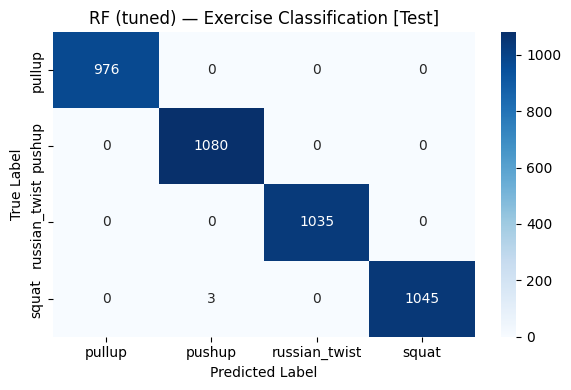


  RF (tuned) — Correctness Classification [Test]
  Accuracy : 0.8183
  F1 Score : 0.8174 (weighted)

              precision    recall  f1-score   support

   incorrect       0.78      0.89      0.83      2051
     correct       0.87      0.75      0.81      2088

    accuracy                           0.82      4139
   macro avg       0.83      0.82      0.82      4139
weighted avg       0.83      0.82      0.82      4139



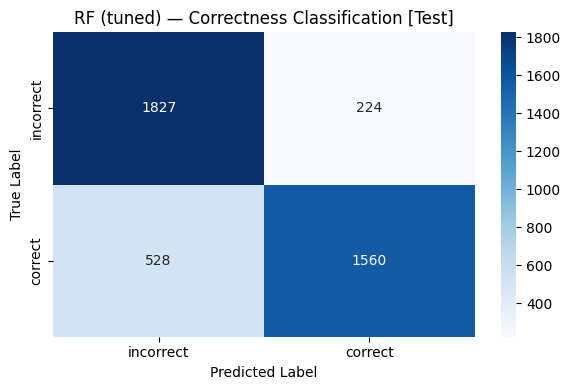


  SVM (tuned) — Exercise Classification [Test]
  Accuracy : 0.9981
  F1 Score : 0.9981 (weighted)

               precision    recall  f1-score   support

       pullup       1.00      1.00      1.00       976
       pushup       1.00      1.00      1.00      1080
russian_twist       1.00      1.00      1.00      1035
        squat       1.00      0.99      1.00      1048

     accuracy                           1.00      4139
    macro avg       1.00      1.00      1.00      4139
 weighted avg       1.00      1.00      1.00      4139



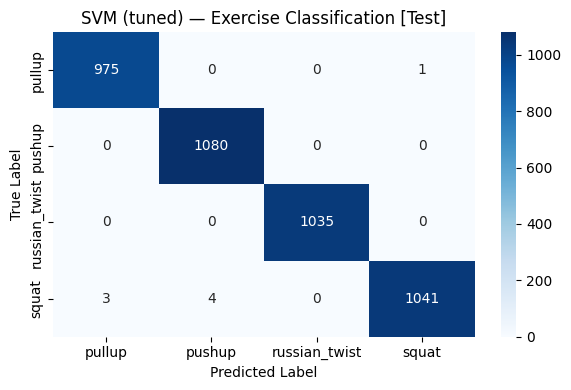


  SVM (tuned) — Correctness Classification [Test]
  Accuracy : 0.8000
  F1 Score : 0.7991 (weighted)

              precision    recall  f1-score   support

   incorrect       0.76      0.87      0.81      2051
     correct       0.85      0.73      0.79      2088

    accuracy                           0.80      4139
   macro avg       0.81      0.80      0.80      4139
weighted avg       0.81      0.80      0.80      4139



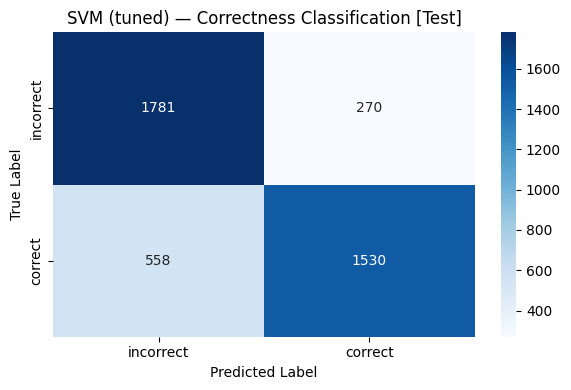

,model,task,accuracy,f1,version
1,RF,Correctness Classification,0.8183,0.8174,tuned
0,RF,Exercise Classification,0.9993,0.9993,tuned
1,Random Forest,Correctness Classification,0.8166,0.8157,baseline
0,Random Forest,Exercise Classification,0.9990,0.9990,baseline
3,SVM,Correctness Classification,0.8062,0.8055,baseline
3,SVM,Correctness Classification,0.8000,0.7991,tuned
2,SVM,Exercise Classification,0.9978,0.9978,baseline
2,SVM,Exercise Classification,0.9981,0.9981,tuned



💾 Tuned models saved to data/models/


In [12]:
# ── Evaluate tuned models on test set ────────────────────────
print("\n" + "="*60)
print("  TUNED MODEL RESULTS — TEST SET")
print("="*60)

tuned_results = []

for model, X, y, label_map, model_name, task_name in [
    (rf_ex_tuned,   X_test,     y_ex_test,  EXERCISE_NAMES,    "RF (tuned)",  "Exercise Classification"),
    (rf_cor_tuned,  X_test_cor, y_cor_test, CORRECTNESS_NAMES, "RF (tuned)",  "Correctness Classification"),
    (svm_ex_tuned,  X_test,     y_ex_test,  EXERCISE_NAMES,    "SVM (tuned)", "Exercise Classification"),
    (svm_cor_tuned, X_test_cor, y_cor_test, CORRECTNESS_NAMES, "SVM (tuned)", "Correctness Classification"),
]:
    tuned_results.append(evaluate_model(
        model=model, X=X, y=y, label_map=label_map,
        model_name=model_name, task_name=task_name, split_name="Test"
    ))

# ── Comparison table: baseline vs tuned ───────────────────────
MODELS_DIR / "model_comparison.csv"
baseline = pd.read_csv(MODELS_DIR / "model_comparison.csv")
baseline["version"] = "baseline"

tuned_df = pd.DataFrame(tuned_results)[["model", "task", "accuracy", "f1"]]
tuned_df["model"]   = tuned_df["model"].str.replace(" (tuned)", "", regex=False)
tuned_df["version"] = "tuned"
tuned_df["accuracy"] = tuned_df["accuracy"].round(4)
tuned_df["f1"]       = tuned_df["f1"].round(4)

comparison = pd.concat([baseline, tuned_df]).sort_values(["model", "task", "version"])
print("\n")
display(comparison)

# ── Save tuned models ─────────────────────────────────────────
joblib.dump(rf_ex_tuned,   MODELS_DIR / "rf_exercise_tuned.pkl")
joblib.dump(rf_cor_tuned,  MODELS_DIR / "rf_correctness_tuned.pkl")
joblib.dump(svm_ex_tuned,  MODELS_DIR / "svm_exercise_tuned.pkl")
joblib.dump(svm_cor_tuned, MODELS_DIR / "svm_correctness_tuned.pkl")
print("\n💾 Tuned models saved to data/models/")
